## Lab 2: Differential Diagnosis and Conditional Expectation

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
import graphviz

# Load data
df = pd.read_csv('./data/ed_visits_probability_lab_train.csv')
test = pd.read_csv('./data/ed_visits_probability_lab_test.csv')


A differential diagnosis is when a health care provider uses the availability of information about different symptoms to try to narrow down the set of possible health problems a patient might be experiencing, before recommending further testing or treatment.

We are not doctors, but we do have the National Hospital Ambulatory Medical Care Survey. The version we will use is **heavily** cleaned and simplified for our lab, please do not use it for research or any other purposes.

Here are the key pieces, in `./data/ed_visits_probability_lab_train.csv` and `./data/ed_visits_probability_lab_test.csv` files both contain:
- The patient's International Classification of Diseases (ICD) code has been simplified in the `disease_group` variable, with 18 categories like `cardiovascular` or `neurological`.
- There are binary symptoms: 'abdominal_pain', 'cough',
       'vomiting', 'fever', 'nausea', 'chest_pain', 'shortness_of_breath',
       'headache', 'accident', 'dizziness', 'back_pain', 'anxiety',
       'skin_rash'
- There are some other variables that likely have predictive value: `sex`, `arrival_by_ambulance`, and age group bins for under 20, 20-40, 40-60, 60-70, and over 70.

Note that you might have a skin rash because you have seborrheic dermatitis, and the underlying condition is actually Parkinson's Disease, which is neurological in nature. Likewise, a person who arrives in an ambulance with chest pain might be having a heart attack, but a walk-in with slight pain might be having an aortic dissection. Just because you have one kind of symptom that is representative of one class of diseases doesn't rule out complex or unexpected causes.

We are going to use the Decision Tree Classifier to learn more about conditional expectation. **This is not a lab about machine learning.** The decision tree classifier splits the sample according to questions about symptoms as it moves through the tree, and computes a probability mass function at each step that represents the proportions of the remaining part of the population with each of the disease codes.

## Step 1:

Run the code below, installing `scikit-learn` and `graphviz` as necessary.

In [17]:
# Symptom variables
symptoms = [
    'abdominal_pain', 'cough', 'vomiting', 'fever', 'nausea',
    'chest_pain', 'shortness_of_breath', 'headache', 'accident',
    'dizziness', 'back_pain', 'anxiety', 'skin_rash',
]

# Patient-context variables
patient_vars = [
    'arrival_by_ambulance', 'sex',
    'age_u20', 'age_20_40', 'age_40_60', 'age_60_70', 'age_o70',
]

x_vars = symptoms + patient_vars

# Explanatory-variable matrices
X = df[x_vars].to_numpy()
X_test = test[x_vars].to_numpy()

print('Disease groups:')
print(df['disease_group'].value_counts())


Disease groups:
disease_group
injury_trauma               17711
general_constitutional       8048
other                        5924
ear_nose_throat_eye          4800
gastrointestinal             3911
genitourinary_renal          3796
respiratory                  3688
psychiatric_behavioral       3637
musculoskeletal              3430
infectious_disease           2988
cardiovascular               2320
endocrine_metabolic          2012
dermatologic                 1811
injury_adverse_care          1511
neurological                 1270
pregnancy_related            1237
injury_poisoning              779
hepatobiliary_pancreatic      618
Name: count, dtype: int64


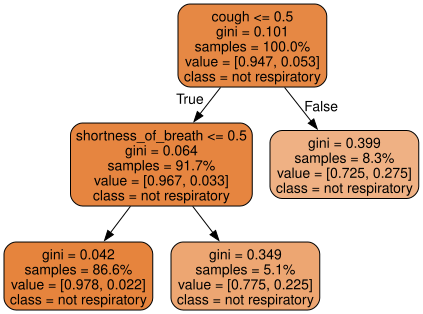

In [24]:
# Set outcome variable:
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 0.001, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

The above object is a **decision tree classifier**: It predicts class labels on the basis of covariates. At each **node** in the graph, there is a condition, like `cough<=.5`. Depending on how the case evaluates, we move left (`True`) or right (`False`) down the tree along the **edges**. At each node, we also see the probability mass function, conditional on the current information set. At the bottom of the tree are **terminal leaves** with hard classification predictions and the final proportions.

The tree classifier pictured in the previous code chunk provides the probability mass function over the labels "not respiratory" and "respiratory". It starts as 95% of patients not having a respiratory problem, and 5% having a respiratory problem. The first differential diagnosis question is, "Does the patient have a cough?" If they do have a cough, we update our estimate to .73/.27, and if not, we update to .97/.03. If you have a cough, shortness of breath, you reach the highest estimate, .59/.41.

This is exactly what conditional probability and conditional expectation are: We update our beliefs based on evidence, and that reshapes our posterior estimates of the probabilities of different outcomes.

The probabilities displayed by the tree are fitted conditional estimates: they are the training-data class proportions among patients reaching each node. They are useful for this lab, but they are not calibrated clinical risk estimates.

<div class="alert alert-block alert-warning">

Which combinations of symptoms make a respiratory disease the most likely explanation? The least likely?

In looking for the combination of symptoms that make a respiratory disease most likely, it would be for patients that have a cough and shortness of breath, as this is a 41.5 percent probability according to the data. The least likely combination is people with no cough, no shortness of breath, and no fever as just 1.8 percent of people have respiratory disease with this combination according to the data.

Which variables does the tree exploit? 

The variables that the tree exploits are cough, shortness of breath, fever, chest pain, dizziness, and arrival by ambulance.

Clearly explain how the tree is a representation of conditional updating, where we condition on reported symptoms to provide new probability estimates based on new information.

At first, we can see at the top of the tree that given no information, the probability that someone has the respiratory disease is 0.053, and this includes all of the sample because we are not conditioning anything. However, as we move along the tree, the sample percentage gets lower which shows conditional updating because conditions kind of subset the data to only people with that condition (what we divide by in conditional probability). For example, at the first split of people having a cough or no cough, there is only 8.3 percent of people with a cough, which is used as the denominator now in the conditional probability. Also in looking at this cough, this extra information completely changes the probability of someone having a respiratory disease as now 27.5 percent of people with a cough have the disease. This shows conditional updating because at each split, the probability of someone having the respiratory disease changes as more information is given to us, allowing us to update the posterior probability.

Run the code again, but try values of 1e-3=0.001, 1e-5=0.00001 and 1e-7=0.0000001 for `min_impurity_decrease` to allow it to explore more complex explanations of the data. For each value of the `min_impurity_decrease` hyperparameter, find the terminal leaves with the lowest and highest probabilities of respiratory disease. How do these values vary with the complexity of the tree?

For 0.001: Terminal leaf with lowest probability of respiratory disease is no cough and no shortness of breath(probability of 0.022). Terminal leaf with highest probability of respiratory disease is having a cough(probability of 0.275). 

For 0.00001: Terminal leaf with lowest probability of respiratory disease is no cough, no shortness of breath, no fever, no chest pain, and yes to accident(probability of 0). Terminal leaf with highest probability of respiratory disease is having a cough, having shortness of breath, no chest pain, no headache, being over 70 years old, and patient sex being 0 (not sure if male or female from codebook). This has probability of 0.555 for having respiratory disease. 

For 0.0000001: Terminal leaf with lowest probability of respiratory disease is probability of 0. Terminal leaf with highest probability of respiratory disease has probability of 0.577. 

The trees get a lot more complex as the min_impurity_decrease gets lower. This is why for 0.0000001, I couldn't even list the path because there is a lot happening. With these more complex trees, it allows the data to be subset more, which allows terminal nodes to have more extreme values. For example, in the lower values of min_impurity_decrease, we saw some termindal nodes have majority of people have the respiratory disease, which is not seen in the higher values of the min_impurity_decrease.

</div>

<div class="alert alert-block alert-warning">

Repeat the previous step with `disease = 'neurological'` and `min_impurity_decrease = 1e-3`. What variables are used in the tree? Which variables raise or lower the predicted probability of a neurological diagnosis?

</div>

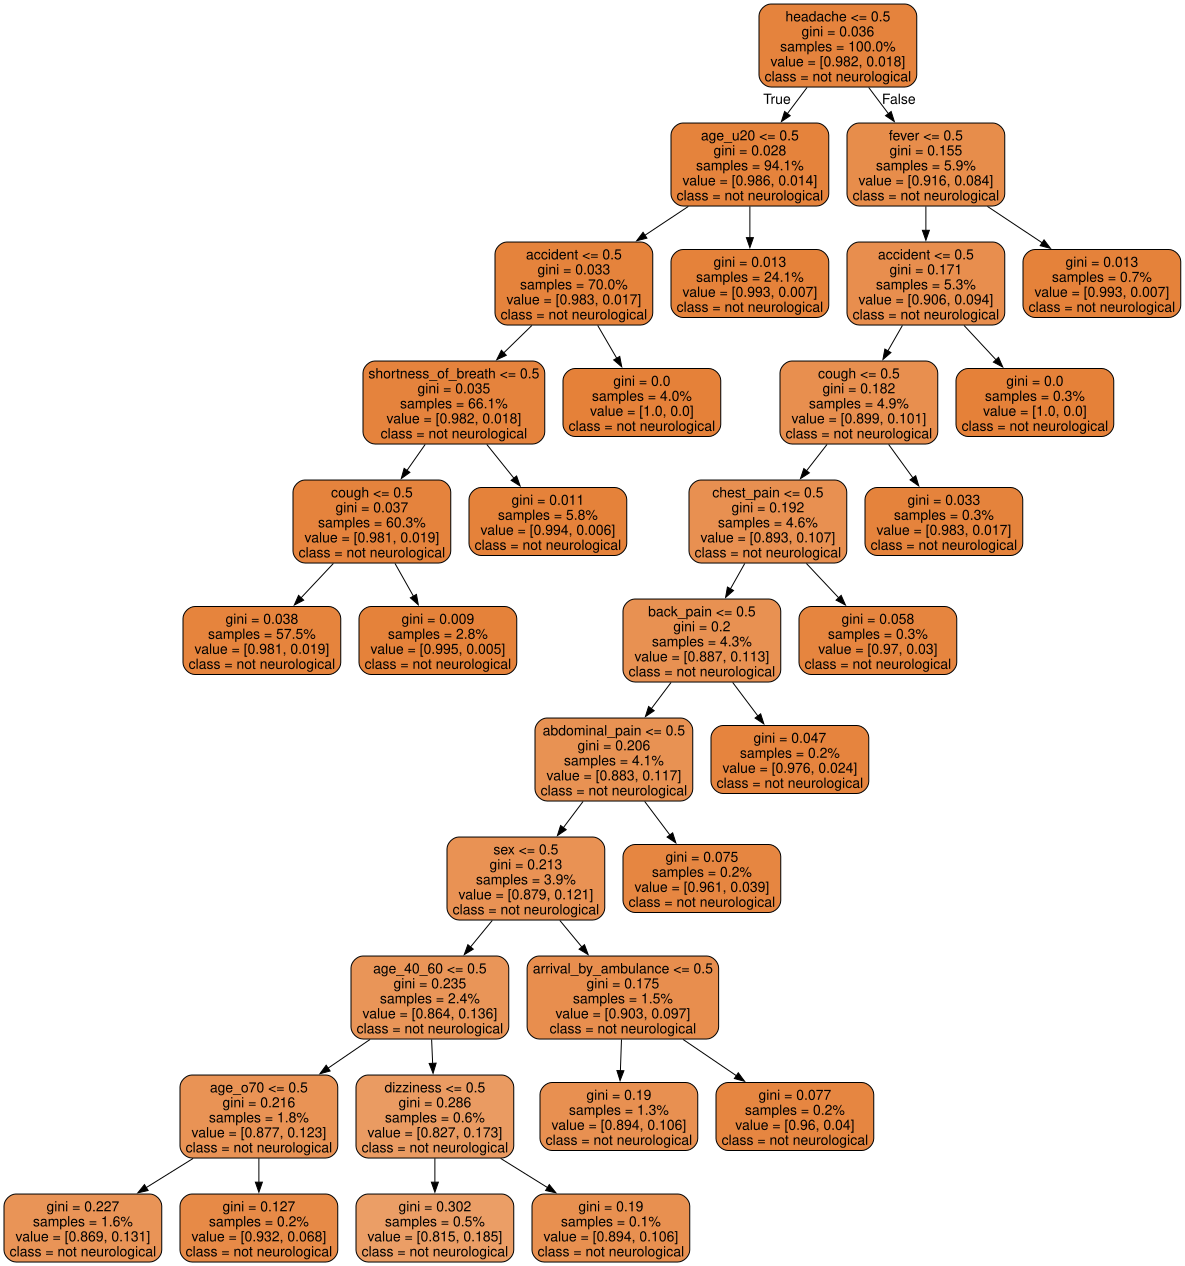

In [23]:
# Set outcome variable:
disease = 'neurological'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 0.00001, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

For 0.001: There is only one terminal leaf with no symptoms attached, which means this tree is just the probability someone has the neurological disease. 98.2 percent of people do not have the disease.

For 0.00001: Terminal leaf with lowest probability of neurological disease is no headache, not under 20, and having an accident(probability of 0). Terminal leaf with highest probability of neurological disease is having a headache, not having a fever, no accident, no cough, no chest pain, no back pain, no abdominal pain, sex of 0, between 40-60 years old, and no dizziness. This has probability of 0.185 for having neurological disease. 

For 0.0000001: Terminal leaf with lowest probability of neurological disease is probability of 0. Terminal leaf with highest probability of neurological disease has probability of 0.185. 

The trees get a lot more complex as the min_impurity_decrease gets lower. This is why for 0.0000001, I couldn't even list the path because there is a lot happening. With these more complex trees, it allows the data to be subset more, which allows terminal nodes to have more extreme values. For example, in the lower values of min_impurity_decrease, we saw some termindal nodes have majority of people have the respiratory disease, which is not seen in the higher values of the min_impurity_decrease. Furthermore, it can also be seen that as the complexity gets higher, we see more symptoms put up in the trees, which further shows the trees get more complex as min_impurity_decrease goes down.

## Step 2:

In step 1, we tried to predict whether a patient has a single condition or not. Now, we want to predict the entire probability mass function.

The code block sets `y = df['disease_group']` and `outcome = df['disease_group'].unique()`, and runs a similar analysis. The result is now a fitted differential diagnosis: an estimated probability mass function over the labels and a hard classification label. For readability, we set `max_depth = 3`.

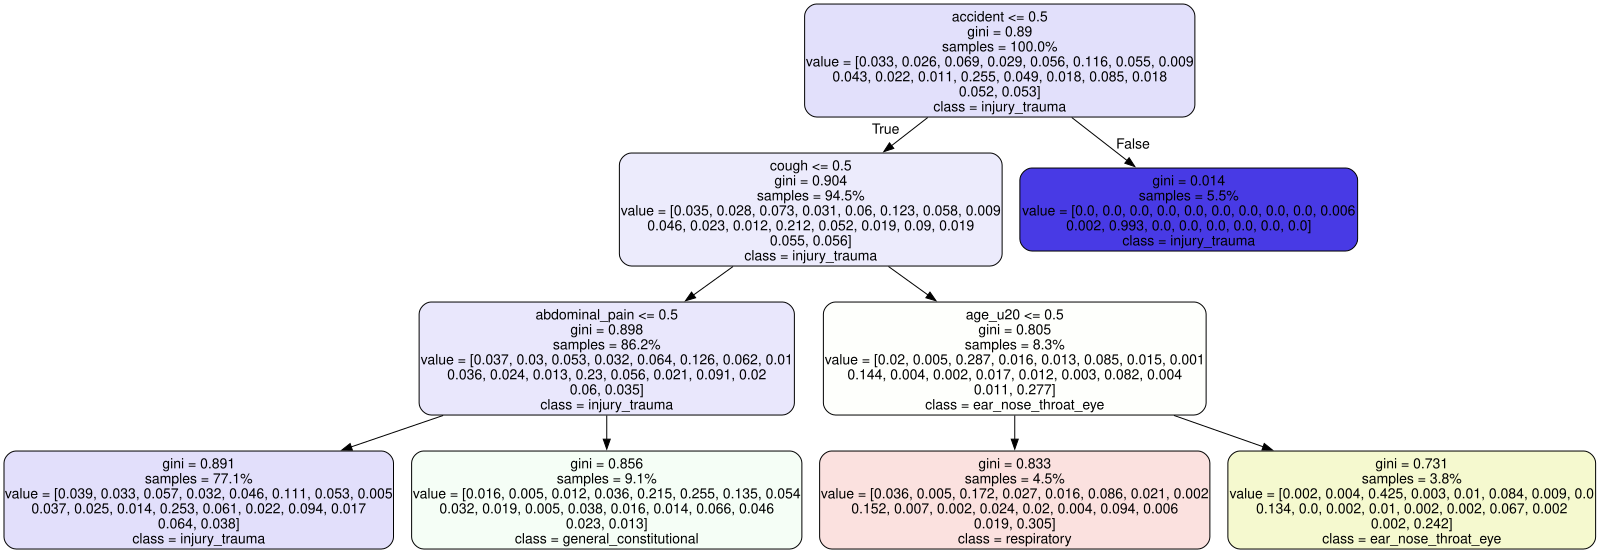

In [20]:
# Set outcome variable:
y = df['disease_group']
## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 3, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)


# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=model.classes_,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

<div class="alert alert-block alert-warning">

Which diseases are predicted as hard classifications in the tree? For those labels, does the probability of that disease exceed even a moderate value like .3 or .5, or not? Why might this be a concern?

Diseases predicted are injury trauma, ear nose throat eye, respiratory, and general constitutional. For these, we see a probability of 0.993 when there was an accident. For every other case though when there wasn't an accident, it seems like the highest the value gets is 0.305. This might be a concern because we are classifying something when it is unlikely to happen. 30.5 percent is not a very high chance of happening, but this is what the classification chooses. This seems to disregarrd the other 60 some percent chance of something else being the case, which is more likely.

Which labels have the highest or lowest probabilities for the predicted disease class labels? 

The label with the highest probability is when there is an accident, the probability of injury trauma is 0.993. The lowest looks to be for general consitutional at 0.255 with no accident, no cough, and there is abdominal pain.

Which conditions and values are used in the tree?

The root split is having an accident or not. Then, if the person did not have an accident, there is a condition of whether the person has a cough or not. For the next depth, there is also a split based on whether someone has abdominal pain as well as if someone is under the age of 20. All of these conditions are split by the value of 0.5, which essentailly just makes it a split into a yes or no since these are categorical variables.

Even if the probabilities for each terminal leaf remain fairly small in absolute terms, why can a differential diagnosis tool like this still be useful for doctors?

These tools are still useful for doctors because one thing is that the very low probabilities can rule out some conditions, which can be helpful. Also, if a probability is like 1 percent jumps to 20 percent at a split, this is a 20 times bigger probability, which can mean a lot to a doctor. This may tell them that even though the probability may still be low, it is still worth looking into and maybe ordering a test because the probability jumped a lot relative to what is was before the condition. 

</div>

In [22]:
df['disease_group'].unique()

<StringArray>
[          'cardiovascular',         'injury_poisoning',
             'dermatologic',                    'other',
            'injury_trauma',      'injury_adverse_care',
              'respiratory',          'musculoskeletal',
      'ear_nose_throat_eye',       'infectious_disease',
   'psychiatric_behavioral',   'general_constitutional',
      'endocrine_metabolic',      'genitourinary_renal',
             'neurological',         'gastrointestinal',
        'pregnancy_related', 'hepatobiliary_pancreatic']
Length: 18, dtype: str